#### [ 연속영역분할 5: 그랩컷 (GrabCut) ] <hr>

- 사용자가 지정한 사각형 또는 마스크를 바탕으로 **전경 객체와 배경을 분리하는 기법**
- 마스크 값:
    * `0`: 확실한 배경
    * `1`: 확실한 전경
    * `2`: 배경일 가능성이 높은 영역
    * `3`: 전경일 가능성이 높은 영역

In [1]:
## ---------------------------------------------
## 모듈 로딩
## ---------------------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(r'D:\KDT\VS_KDT_14\[7]_CV')
from cv_utils import *

- **[1] 임의의 원본 이미지 만들기**

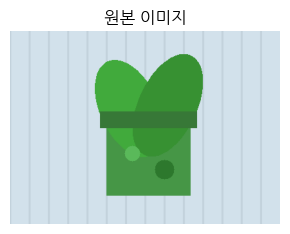

In [3]:
## ---------------------------------------------
## 실습 이미지 데이터 생성
## ---------------------------------------------
## 임의의 데이터 생성
H, W = 300, 420
imageNP = np.full((H, W, 3), (235, 225, 210), dtype=np.uint8)

for x in range(0, W, 30):
    cv2.line(imageNP, (x, 0), (x, H), (220, 210, 195), 2)

cv2.rectangle(imageNP, (150, 135), (280, 255), (70, 150, 70), -1)
cv2.ellipse(imageNP, (185, 120), (45, 80), -25, 0, 360, (60, 170, 65), -1)
cv2.ellipse(imageNP, (245, 115), (45, 85), 25, 0, 360, (50, 145, 55), -1)
cv2.rectangle(imageNP, (140, 125), (290, 150), (55, 120, 55), -1)
cv2.circle(imageNP, (190, 190), 12, (90, 185, 90), -1)
cv2.circle(imageNP, (240, 215), 15, (45, 120, 45), -1)


## 시각화 출력
printPlots(1,1,["원본 이미지"], [cv2.cvtColor(imageNP, cv2.COLOR_BGR2RGB)])

- **[2] 전경 객체를 포함하는 사각형 지정**

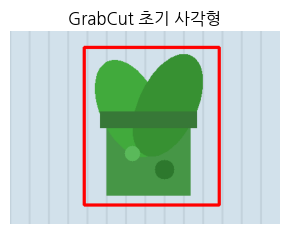

In [ ]:
## => 사용자 임의 지정 사각형
##    (x, y, width, height)
rect = (115, 25, 210, 245)  

## 원본 복사본
rectangle_image = imageNP.copy()

## 이미지에 사각형 그리기
x, y, w, h = rect
cv2.rectangle(rectangle_image, (x, y), (x+w, y+h), (0,0,255), 3)

## 시각화 출력
printPlots(1,1,["GrabCut 초기 사각형"], [cv2.cvtColor(rectangle_image, cv2.COLOR_BGR2RGB)])


- **[3] GrabCut 실행**

In [6]:
## 마스크, 배경, 전경 생성
mask = np.zeros(imageNP.shape[:2], dtype=np.uint8)
background_model = np.zeros((1,65), dtype=np.float64)
foreground_model = np.zeros((1,65), dtype=np.float64)

## 
cv2.grabCut(    imageNP, 
                mask,
                rect,
                background_model,
                foreground_model,
                5,
                cv2.GC_INIT_WITH_RECT )

print('GrabCut 마스크 값:', np.unique(mask))

GrabCut 마스크 값: [0 2 3]


- **[4] 이진 마스크로 변환하고 전경만 추출**

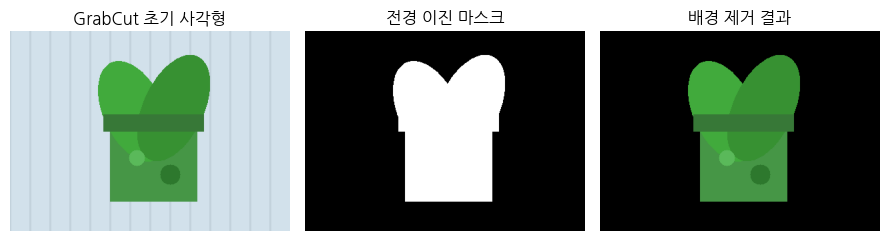

In [9]:
## 전경만 추출
binary_mask = np.where( (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0 ).astype(np.uint8)
result = imageNP * binary_mask[:, :, np.newaxis]

## 시각화 출력
rgbNP    = cv2.cvtColor(imageNP, cv2.COLOR_BGR2RGB)
resultNP = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
rectNP   = cv2.cvtColor(rectangle_image, cv2.COLOR_BGR2RGB)

printPlots(1,3, 
           ["GrabCut 초기 사각형", "전경 이진 마스크", "배경 제거 결과"], 
           [rgbNP,  binary_mask, resultNP], 
           [None, 'gray', None])

## 핵심 정리

- 사각형 안팎의 픽셀 색상 분포를 분석해 전경과 배경을 반복적으로 구분
- 사각형 밖은 확실한 배경으로 취급
- 객체 전체가 사각형 안에 들어가야 함!!!